## Exercise 1: Descriptive statistics with Palmer Penguins

In [2]:
%pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


### A. Concepts: what statistics is and how we use data

1. For this dataset, what is a reasonable population you might want to learn about? What is the sample you actually have in df? (One or two sentences each.)
- Population: This refers to all penguins of the Adélie, Chinstrap, and Gentoo species living on the Palmer Archipelago islands in Antarctica.
- Sample: This refers to the group of 344 penguins listed in Table df whose data were actually measured by scientists during the study period.

2. List every column in df. For each, label it numerical or categorical (if a column could be debated, say why).
- Numerical: bill_length_mm, bill_depth_mm,f lipper_length_mm, body_mass_g.
-categorical: species, island, sex.

3. Give two new examples of variables that are clearly numerical and two that are clearly categorical not in this table (any domain you like).

- Running speed: Measured in kilometers per hour (continuous value).

- Blood type: (A, B, AB, O) These are categories that cannot be mathematically ordered.

### B. Calculations on the sample: proportion, mean, variance


Use the cleaned numeric columns only where needed (drop rows with missing body mass or bill length, or use .dropna(subset=[...]) as you prefer). Show your code and round printed numbers sensibly.




In [3]:
import numpy as np
import pandas as pd
import seaborn as sns

df = sns.load_dataset("penguins")
df.head()

/home/mona/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [4]:
df_clean= df.dropna(subset=['body_mass_g','bill_length_mm'])

df_clean

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


1. For the variable body_mass_g:

    Compute the proportion of penguins with body mass greater than the overall median body mass (among non-missing values).
    Compute the mean and variance of body_mass_g (same subset).

In [5]:
#persent of body mass greater than the overall median body mass
over = df_clean['body_mass_g'].median()
prop_greater = (df_clean['body_mass_g' ] > over).mean()

#mean and variance 
mass_mean = df_clean['body_mass_g'].mean()
mass_val = df_clean['body_mass_g'].var()

print('the persenteg of body mass greater than the overall median body mass', prop_greater)
print('the mean of body mass =',mass_mean)
print('the variance od body mass =',mass_val)


the persenteg of body mass greater than the overall median body mass 0.4853801169590643
the mean of body mass = 4201.754385964912
the variance od body mass = 643131.0773267479


2. For body_mass_g, identify at least two distributional summary measures that describe center and spread (name them and compute them). Optionally add a third that describes shape (e.g. skewness), if you know how to compute it.

In [6]:

mass_data = df_clean['body_mass_g']

mean_val = mass_data.mean()
median_val = mass_data.median()


std_val = mass_data.std()
var_val = mass_data.var()

skew_val = mass_data.skew()


print(f"--- Descriptive Measures for Body Mass ---")
print(f"Center: Mean = {mean_val:.2f}, Median = {median_val:.2f}")
print(f"Spread: Std Dev = {std_val:.2f}, Variance = {var_val:.2f}")
print(f"Shape:  Skewness = {skew_val:.2f}")

--- Descriptive Measures for Body Mass ---
Center: Mean = 4201.75, Median = 4050.00
Spread: Std Dev = 801.95, Variance = 643131.08
Shape:  Skewness = 0.47


### C. Shape of distributions: vocabulary and examples

1. Briefly define each shape in your own words: normal (Gaussian), uniform, skewed, exponential.

- normal/gaussian: is one of the most important distributions in statistics. 
- The probability density function (PDF) of a normal distribution is given by:
- 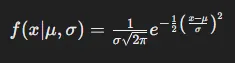

- Where:

    μ is the mean,
    σ is the standard deviation,
    e is the base of the natural logarithm



2. Give two real-world examples of quantities that are often modeled as roughly normally distributed (they need not be perfect). (you can search the internet)

- Throughout humanity (Human Heights): People begin around anemia, after it has been eradicated.

- To group items (Test results): Such as choices; most students get the average grade.


3. Give one example of data that is typically not normal—e.g. exponential-like or strongly skewed—and say why. (you can search the internet)

- Wealth distribution or individual income: it's right-skewed; the vast majority have limited income, while a small number of billionaires pull the distribution "tail" to the right enormously, making the average far removed from reality.

### D. Percentiles and the empirical rule (normal distribution)

Work on body_mass_g (non-missing) or bill_length_mm—pick one and stick to it for this section.

1. In plain language, explain what the 75th percentile of body mass means for a penguin in this sample. 2. Compute the 25th, 50th, and 75th percentiles for your chosen variable.

- percentage of 75 means that this penguin is heavier than the group.

In [7]:
m25 =df_clean['body_mass_g'].quantile(0.25)
m50 =df_clean['body_mass_g'].quantile(0.50)
m75= df_clean['body_mass_g'].quantile(0.75)

print("Body mass statistics 25th =",m25,"Body mass statistics 25th =", m50,"Body mass statistics 75th =",m75)

Body mass statistics 25th = 3550.0 Body mass statistics 25th = 4050.0 Body mass statistics 75th = 4750.0


Assume for discussion that flipper length (or another chosen numeric column) were exactly normal with the mean and standard deviation you observe in the sample.

3. For a normal distribution, explain what share of values fall within 1, 2, and 3 standard deviations of the mean (the empirical rule). Then compute the interval μ±1σμ±1σ, μ±2σμ±2σ, and μ±3σμ±3σ using your sample μμ and σσ for that variable.

In [8]:
mu = df_clean['flipper_length_mm'].mean()
sigma = df_clean['flipper_length_mm'].std()

interval_1std = (mu - sigma, mu + sigma)
interval_2std = (mu - 2*sigma, mu + 2*sigma)
interval_3std = (mu - 3*sigma, mu + 3*sigma)


print(f"Mean (μ): {mu:.2f} mm")
print(f"Std Dev (σ): {sigma:.2f} mm\n")

print(f"Interval μ ± 1σ (68%): {interval_1std[0]:.2f} to {interval_1std[1]:.2f} mm")
print(f"Interval μ ± 2σ (95%): {interval_2std[0]:.2f} to {interval_2std[1]:.2f} mm")
print(f"Interval μ ± 3σ (99.7%): {interval_3std[0]:.2f} to {interval_3std[1]:.2f} mm")

Mean (μ): 200.92 mm
Std Dev (σ): 14.06 mm

Interval μ ± 1σ (68%): 186.85 to 214.98 mm
Interval μ ± 2σ (95%): 172.79 to 229.04 mm
Interval μ ± 3σ (99.7%): 158.73 to 243.10 mm


### E. Box plot: read the graphic

1. (SOLVED) Draw a box plot of body_mass_g, split by species.

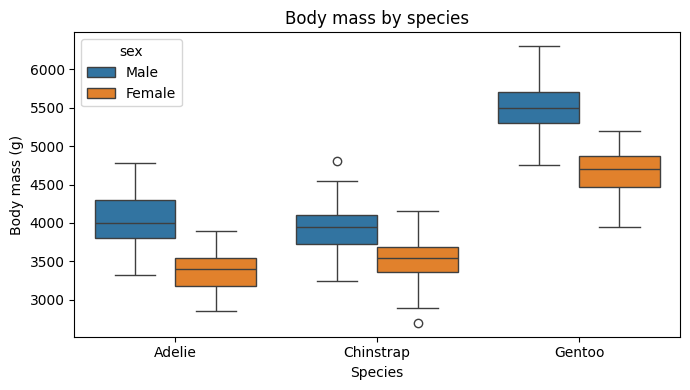

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

df_box = sns.load_dataset("penguins").dropna(subset=["body_mass_g", "species"])

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df_box, x="species", y="body_mass_g", hue='sex', ax=ax)
ax.set_title("Body mass by species")
ax.set_xlabel("Species")
ax.set_ylabel("Body mass (g)")
plt.tight_layout()

2. On your plot, label or describe what each part represents: median, quartiles, whiskers, and points outside the whiskers (if any). What does the box width tell you?

- The line in the middle of each box represents the median.
- The box represents the middle of the data (the interquartile range), covering the middle 50% of the distribution.
- The whiskers indicate the spread and distribution of the data outside the middle range.
- The points outside the whiskers are outliers; they represent penguins with unusual body mass (values that differ significantly from the rest of the sample).


A long box represents high variability in penguin body mass, meaning the data is widely dispersed.

A short box means that the penguin weights are very close to each other, indicating that the data is consistent.

3. Write two sentences about the sample using words like “most” and “few” (e.g. which species tend to be heavier). Base this only on what you see in the plot.

Based on the plot, most Gentoo penguins tend to be significantly heavier than the other two species, while only a few individual penguins appear as outliers with weights far from their group's average.

4. Write one quantitative claim about the data (e.g. “the median body mass of Chinstrap is above 3500 g”). Then verify it with code (groupby, median, etc.) and state whether your claim was true or false.

 - i meade example for quantitative with hypothesis with categorical (species) and numerical (flipper_length_mm). First step i will be draw the boxplot:

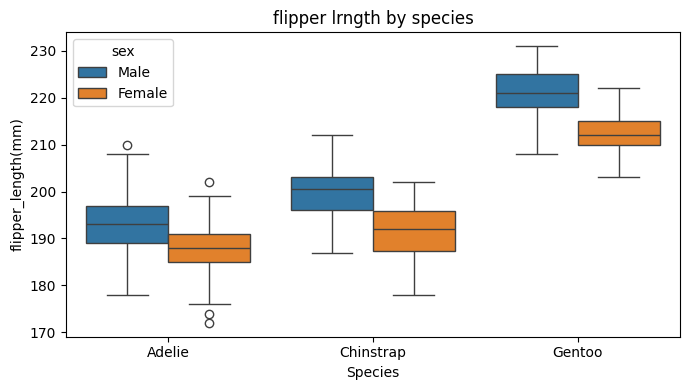

In [10]:
df_box = sns.load_dataset("penguins").dropna(subset=["flipper_length_mm", "species"])

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df_box, x="species", y="flipper_length_mm", hue='sex', ax=ax)
ax.set_title("flipper lrngth by species")
ax.set_xlabel("Species")
ax.set_ylabel("flipper_length(mm)")
plt.tight_layout()

In [12]:
df_f= sns.load_dataset("penguins").dropna(subset=["flipper_length_mm", "species"])

# 2. حساب الوسيط لكل فصيلة

medians = df_f.groupby("species", observed=True)["flipper_length_mm"].median()

print("Median Flipper Length (mm) by species:")
print(medians)


target_species = "Chinstrap"
target_median = medians.get(target_species)
claim_value = 190  # اخترنا 190 بناءً على قراءتنا للرسم

print(f"\nExample claim: {target_species} median > {claim_value} mm")
print(f"  {target_species} median:", target_median)
print(f"  Claim is true:", target_median > claim_value)

Median Flipper Length (mm) by species:
species
Adelie       190.0
Chinstrap    196.0
Gentoo       216.0
Name: flipper_length_mm, dtype: float64

Example claim: Chinstrap median > 190 mm
  Chinstrap median: 196.0
  Claim is true: True


- finel quantitiative Based on the plot: most Gentoo penguins have significantly longer flippers than the Adelie and Chinstrap species. Additionally, within each species, a few male penguins tend to have longer flippers than females, with very few outliers appearing in the sample.

Use the cell below as a starting point: it prints medians by species and shows one example check (Chinstrap median vs 3500 g). Adapt the last lines to match your claim.

In [11]:
import seaborn as sns

df_v = sns.load_dataset("penguins").dropna(subset=["body_mass_g", "species"])

medians = df_v.groupby("species", observed=True)["body_mass_g"].median()
print("Median body mass (g) by species:")
print(medians)

# Example verification — replace with checks that match your own claim
chin_median = medians.get("Chinstrap")
print("\nExample claim: Chinstrap median > 3500 g")
print("  Chinstrap median:", chin_median)
print("  Claim is true:", chin_median > 3500)

Median body mass (g) by species:
species
Adelie       3700.0
Chinstrap    3700.0
Gentoo       5000.0
Name: body_mass_g, dtype: float64

Example claim: Chinstrap median > 3500 g
  Chinstrap median: 3700.0
  Claim is true: True


### F. Outliers

1. Name two methods for identifying or removing outliers on a numeric column. For each, give a one-sentence explanation of the rule. Then show one method applied in code to flag outliers in bill_length_mm (do not delete them from the full dataset the count or indices is enough).

In [13]:

df = sns.load_dataset("penguins").dropna(subset=["bill_length_mm"])

Q1 = df['bill_length_mm'].quantile(0.25)
Q3 = df['bill_length_mm'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 3. تحديد القيم المتطرفة (Flagging)
outliers = df[(df['bill_length_mm'] < lower_bound) | (df['bill_length_mm'] > upper_bound)]

print(f"Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")
print(f"Number of outliers found in bill_length_mm: {len(outliers)}")

if not outliers.empty:
    print("Indices of outliers:")
    print(outliers.index.tolist())

Lower Bound: 25.31, Upper Bound: 62.41
Number of outliers found in bill_length_mm: 0
